In [ ]:
from md_Helpers import eos_sweep
from md_Helpers.paths import MASTER_CSVS_V3_ROOT

n_values = [10, 15, 20, 25, 30]

for n in n_values:
    print("=" * 80)
    print("Rebuilding EOS pressure-window sweep for n_cells =", n)

    table = eos_sweep.run_eos_pressure_window_sweep(
        n_fcc_cells=n,
        kT_start=0.700,
        kT_stop=1.000,
        kT_step=0.050,
        initial_rho=0.730,
        rho_step=0.005,
        nsteps=1_000_000,
        log_period=1_000,
        seed=1,
        overwrite=False,
        overwrite_lattice=False,
        stop_down_on_phase_separation=True,
        continue_on_error=True,
        output_path=MASTER_CSVS_V3_ROOT / f"adaptive_pressure_window_ncells_{n}.csv",
    )

    eos_sweep.plot_eos_density_curves(
        table=table,
        n_fcc_cells=n,
        save=True,
        show=True,
    )

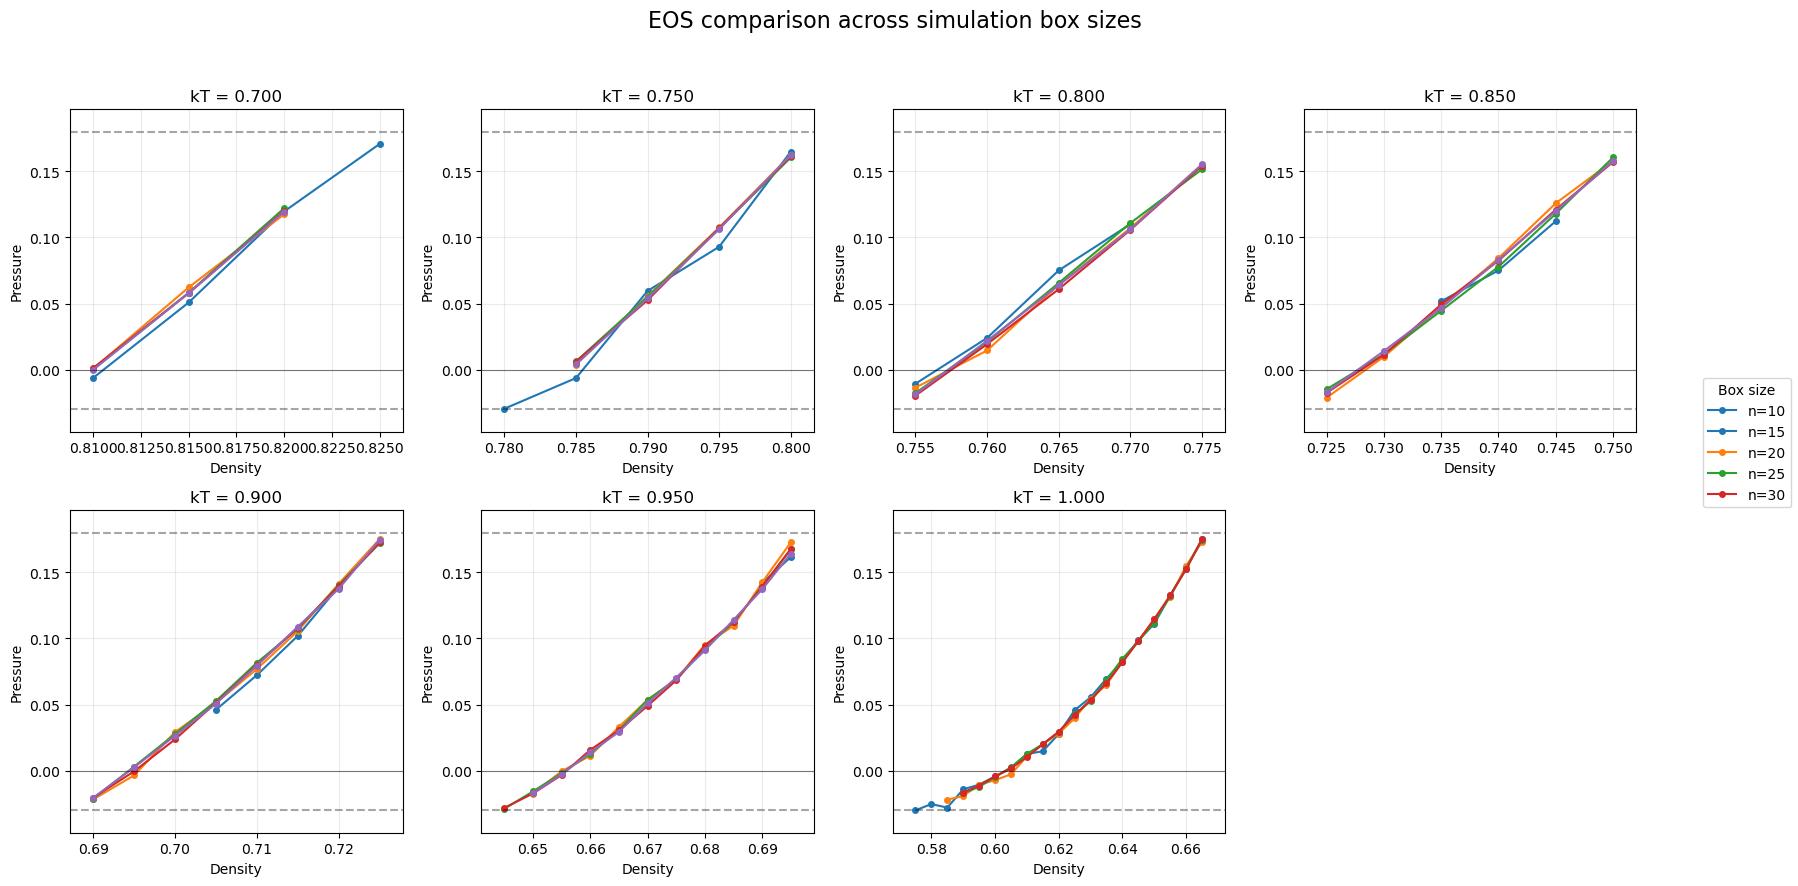

Saved: Plots/EOS/eos_box_size_comparison_pressure_window.png


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers.paths import MASTER_CSVS_V3_ROOT

n_values = [10, 15, 20, 25, 30]
kT_values = np.arange(0.700, 1.000 + 0.025, 0.050)

pressure_col = "pressure_mean_last100"
pressure_min = -0.03
pressure_max = 0.18

# Load the complete sweeps. These tables remain unchanged.
tables = {
    n: pd.read_csv(
        MASTER_CSVS_V3_ROOT
        / f"adaptive_pressure_window_ncells_{n}.csv"
    )
    for n in n_values
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
    sharex=False,
    sharey=False,
)

axes = axes.ravel()

for ax, kT in zip(axes, kT_values):
    for n in n_values:
        table = tables[n]

        # This mask affects only what is plotted.
        plot_mask = (
            np.isclose(table["kT"], kT)
            & table[pressure_col].between(
                pressure_min,
                pressure_max,
                inclusive="both",
            )
            & (~table["phase_separated"].astype(bool))
        )

        selection = (
            table.loc[plot_mask]
            .sort_values("target_rho")
        )

        if selection.empty:
            continue

        ax.plot(
            selection["target_rho"],
            selection[pressure_col],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=f"n={n}",
        )

    ax.axhline(
        pressure_min,
        color="black",
        linestyle="--",
        alpha=0.35,
    )
    ax.axhline(
        pressure_max,
        color="black",
        linestyle="--",
        alpha=0.35,
    )
    ax.axhline(
        0.0,
        color="black",
        linewidth=0.8,
        alpha=0.5,
    )

    ax.set_title(f"kT = {kT:.3f}")
    ax.set_xlabel("Density")
    ax.set_ylabel("Pressure")
    ax.grid(alpha=0.25)
    ax.margins(x=0.08, y=0.08)

# Hide the unused eighth panel.
for ax in axes[len(kT_values):]:
    ax.set_visible(False)

# Collect legend entries from all panels in case the first panel
# does not contain every box size.
legend_entries = {}

for ax in axes[:len(kT_values)]:
    handles, labels = ax.get_legend_handles_labels()

    for handle, label in zip(handles, labels):
        legend_entries[label] = handle

fig.legend(
    legend_entries.values(),
    legend_entries.keys(),
    title="Box size",
    loc="center right",
)

fig.suptitle(
    "EOS comparison across simulation box sizes",
    fontsize=16,
)

fig.tight_layout(rect=[0, 0, 0.92, 0.95])

output_path = "Plots/EOS/eos_box_size_comparison_pressure_window.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", output_path)

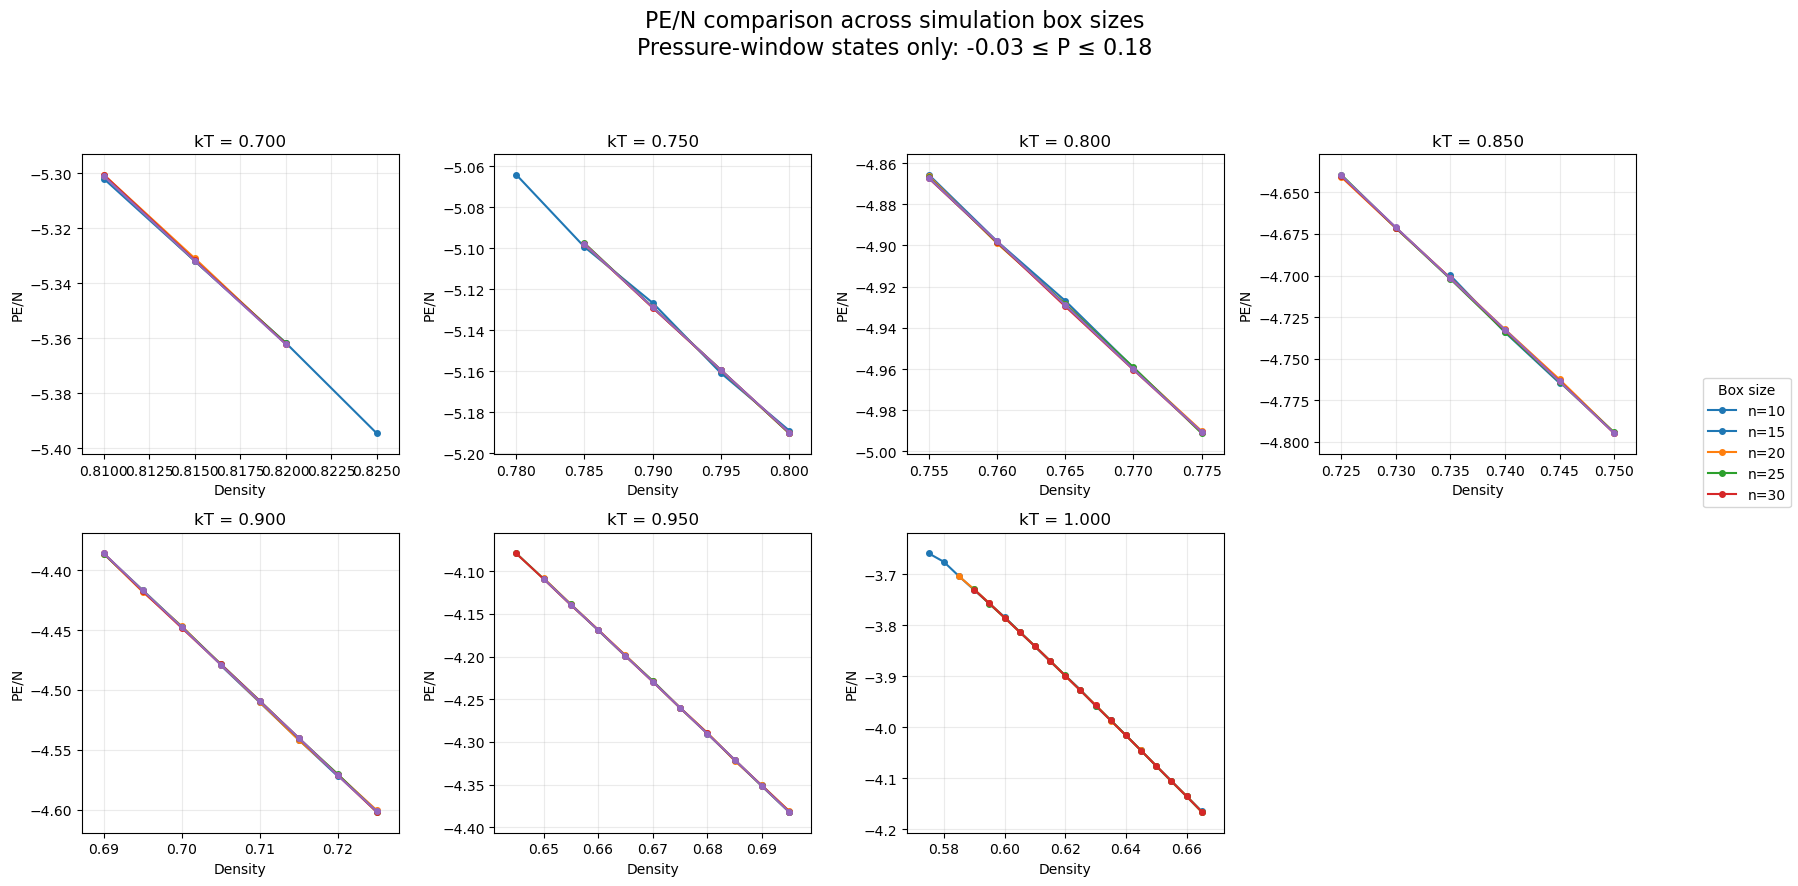

Saved: Plots/EOS/eos_box_size_comparison_PE_per_particle.png


In [8]:
pe_col = "PE_per_particle_mean_last100"
pressure_col = "pressure_mean_last100"

pressure_min = -0.03
pressure_max = 0.18

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
    sharex=False,
    sharey=False,
)

axes = axes.ravel()

for ax, kT in zip(axes, kT_values):
    for n in n_values:
        table = tables[n]

        # Use pressure to select the window, but plot PE/N.
        plot_mask = (
            np.isclose(table["kT"], kT)
            & table[pressure_col].between(
                pressure_min,
                pressure_max,
                inclusive="both",
            )
            & (~table["phase_separated"].astype(bool))
            & table[pe_col].notna()
        )

        selection = (
            table.loc[plot_mask]
            .sort_values("target_rho")
        )

        if selection.empty:
            continue

        ax.plot(
            selection["target_rho"],
            selection[pe_col],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=f"n={n}",
        )

    ax.set_title(f"kT = {kT:.3f}")
    ax.set_xlabel("Density")
    ax.set_ylabel("PE/N")
    ax.grid(alpha=0.25)
    ax.margins(x=0.08, y=0.08)

# Hide the unused eighth panel.
for ax in axes[len(kT_values):]:
    ax.set_visible(False)

# Collect legend entries across all panels.
legend_entries = {}

for ax in axes[:len(kT_values)]:
    handles, labels = ax.get_legend_handles_labels()

    for handle, label in zip(handles, labels):
        legend_entries[label] = handle

fig.legend(
    legend_entries.values(),
    legend_entries.keys(),
    title="Box size",
    loc="center right",
)

fig.suptitle(
    "PE/N comparison across simulation box sizes\n"
    f"Pressure-window states only: {pressure_min} ≤ P ≤ {pressure_max}",
    fontsize=16,
)

fig.tight_layout(rect=[0, 0, 0.92, 0.93])

output_path = "Plots/EOS/eos_box_size_comparison_PE_per_particle.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", output_path)